In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from functions import *
from scipy.linalg import toeplitz
from scipy.signal import find_peaks

plt.rcParams.update({'font.size': 12})

C:\Users\Tadej\AppData\Local\Temp\ipykernel_534016\4108382871.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Read the file with space-separated values using regex to match multiple spaces
luna = pd.read_csv("data/luna.dat", delimiter=r'\s+', skiprows=1)

luna['x'] = np.cos(luna['Dec[stopinje]'] * (np.pi/180)) * np.cos(luna['RA[h]'] * 15 * (np.pi/180))
luna['y'] = np.cos(luna['Dec[stopinje]'] * (np.pi/180)) * np.sin(luna['RA[h]'] * 15 * (np.pi/180))
luna['z'] = np.sin(luna['Dec[stopinje]'] * (np.pi/180))

# Check the data
print(luna.head())

  datum     RA[h]  Dec[stopinje]         x         y         z
0  JAN1  18.26483      -19.45378  0.065322 -0.940645 -0.333046
1  JAN2  19.29967      -17.55858  0.318177 -0.898750 -0.301681
2  JAN3  20.28822      -14.56047  0.545752 -0.799345 -0.251402
3  JAN4  21.22175      -10.77597  0.733771 -0.653163 -0.186969
4  JAN5  22.10244       -6.52906  0.873420 -0.473506 -0.113707


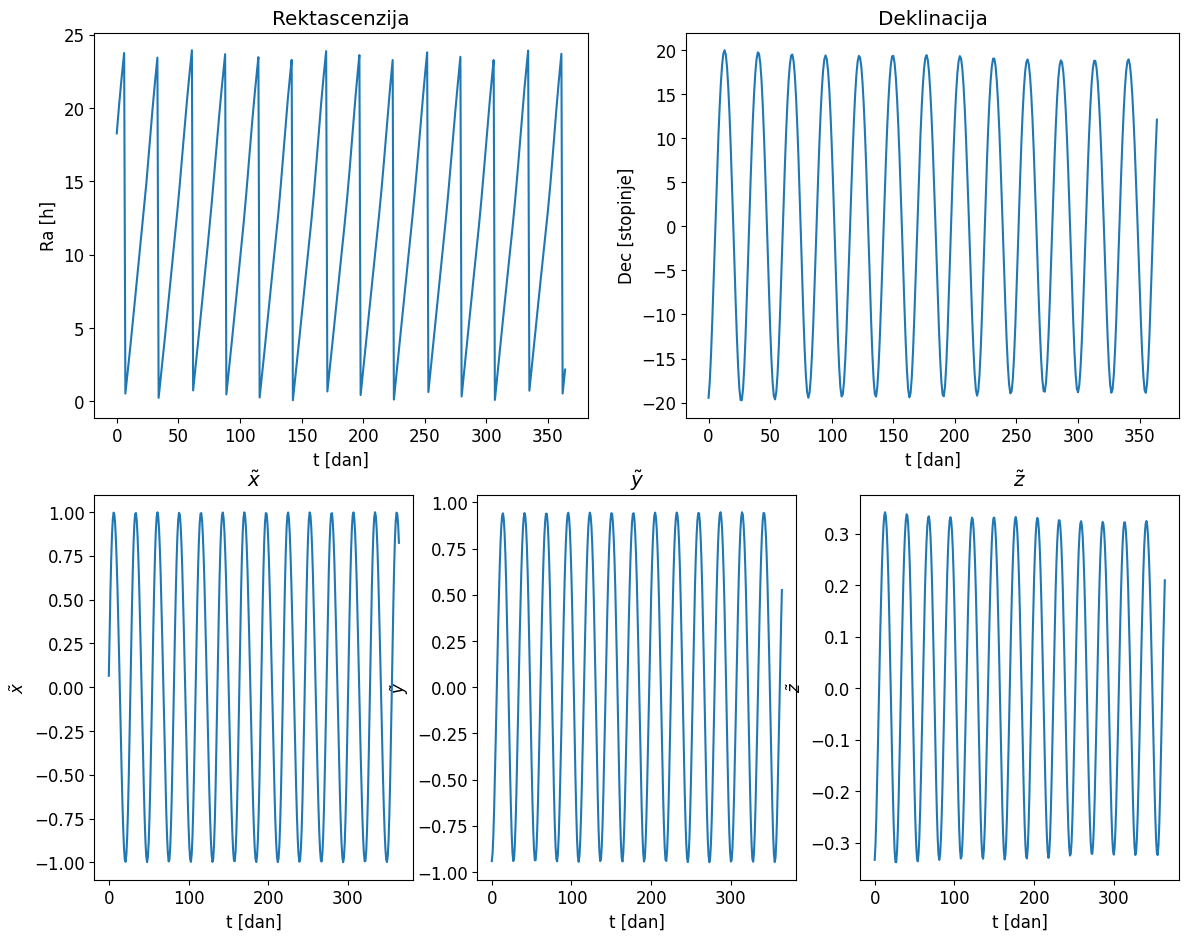

In [3]:
fig = plt.figure(figsize=(14, 11))

ax = fig.add_subplot(2, 2, 1)
ax.set_title('Rektascenzija')
ax.set_ylabel('Ra [h]')
ax.set_xlabel('t [dan]')
ax.plot(luna.index[:365], luna['RA[h]'][:365])

ax = fig.add_subplot(2, 2, 2)
ax.set_title('Deklinacija')
ax.set_ylabel('Dec [stopinje]')
ax.set_xlabel('t [dan]')
ax.plot(luna.index[:365], luna['Dec[stopinje]'][:365])

ax = fig.add_subplot(2, 3, 4)
ax.set_title(r'$\tilde{x}$')
ax.set_ylabel(r'$\tilde{x}$')
ax.set_xlabel('t [dan]')
ax.plot(luna.index[:365], luna['x'][:365])

ax = fig.add_subplot(2, 3, 5)
ax.set_title(r'$\tilde{y}$')
ax.set_ylabel(r'$\tilde{y}$')
ax.set_xlabel('t [dan]')
ax.plot(luna.index[:365], luna['y'][:365])

ax = fig.add_subplot(2, 3, 6)
ax.set_title(r'$\tilde{z}$')
ax.set_ylabel(r'$\tilde{z}$')
ax.set_xlabel('t [dan]')
ax.plot(luna.index[:365], luna['z'][:365])


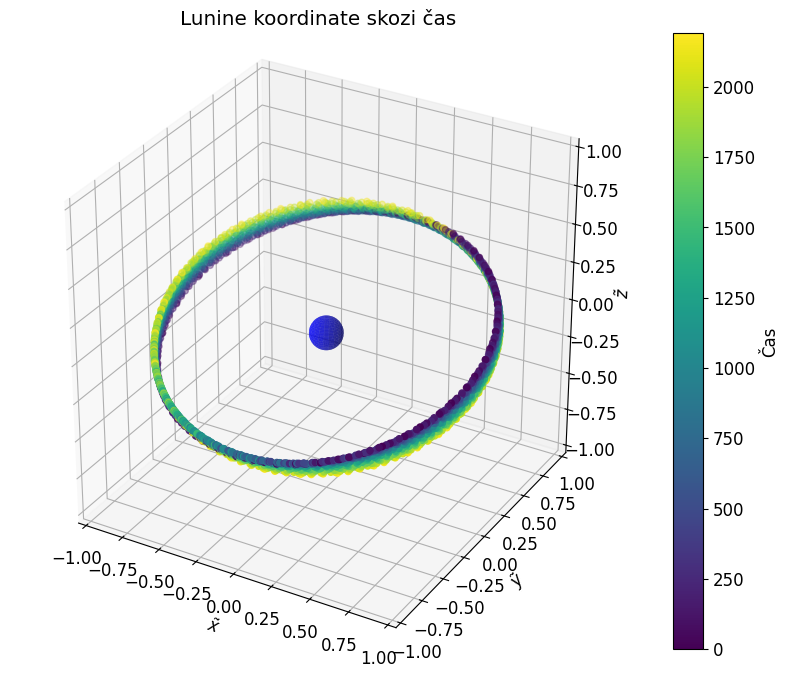

In [4]:
# Normalize time data to use as a colormap scale
time = np.arange(len(luna))  # Assuming time is the index of rows in order
colors = plt.cm.viridis(time / max(time))  # Use the 'viridis' colormap

# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the Moon's coordinates with a color gradient
scatter = ax.scatter(luna['x'], luna['y'], luna['z'], c=time, cmap='viridis', marker='o')

# Create Earth as a sphere at the origin
u = np.linspace(0, 2 * np.pi, 100)  # Azimuth angle
v = np.linspace(0, np.pi, 100)      # Elevation angle
x_earth = 0.1 * np.outer(np.cos(u), np.sin(v))  # X coordinates of the sphere
y_earth = 0.1 * np.outer(np.sin(u), np.sin(v))  # Y coordinates of the sphere
z_earth = 0.1 * np.outer(np.ones_like(u), np.cos(v))  # Z coordinates of the sphere

# Plot the Earth sphere
ax.plot_surface(x_earth, y_earth, z_earth, color='blue', alpha=0.6, rstride=5, cstride=5)

# Add a color bar to indicate time progression
cbar = fig.colorbar(scatter, ax=ax, label='Čas')

# Label the axes
ax.set_xlabel(r'$\tilde{x}$')
ax.set_ylabel(r'$\tilde{y}$')
ax.set_zlabel(r'$\tilde{z}$')

ax.set_xlim((-1.01, 1.01))
ax.set_ylim((-1.01, 1.01))
ax.set_zlim((-1.01, 1.01))

# Add a title
ax.set_title('Lunine koordinate skozi čas')

# Set equal aspect ratio for better visualization
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1

# Show the plot
plt.show()


In [5]:
N = len(luna['Dec[stopinje]'].values)
dt = 1.

nuc = 1. / (2. * dt)
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi
dnu = nus[1]-nus[0]

omegas = np.linspace(0., np.pi, round(N/2))

S2, P2 = DFT(luna['Dec[stopinje]'].values)
S2_Welch, P2_Welch = DFT(luna['Dec[stopinje]'].values, window='Welch')
poles, adjusted_poles, P2_3 = MESE(omegas, luna['Dec[stopinje]'].values, 3, 'Reflect')
poles, adjusted_poles, P2_14 = MESE(omegas, luna['Dec[stopinje]'].values, 4, 'Reflect')
poles, adjusted_poles, P2_25 = MESE(omegas, luna['Dec[stopinje]'].values, 14, 'Reflect')

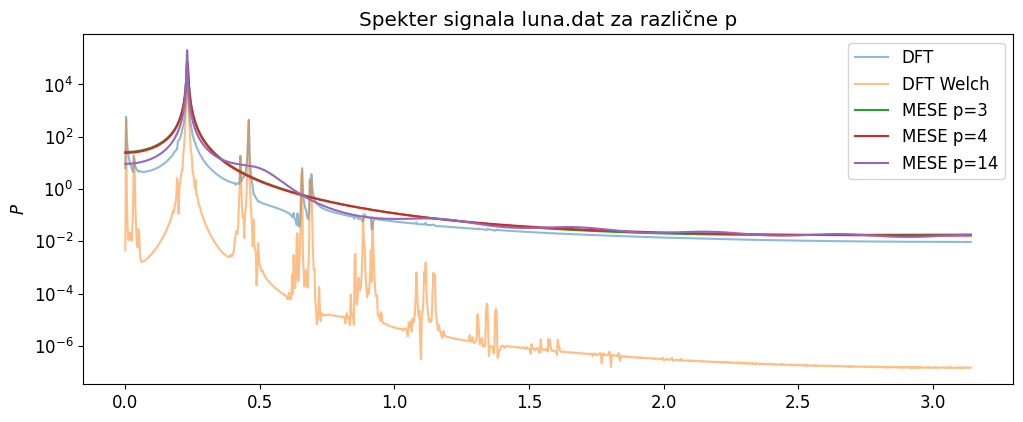

In [6]:
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('Spekter signala luna.dat za različne p')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus, P2, label='DFT', alpha=0.5)
ax.plot(nus, P2_Welch, label='DFT Welch', alpha=0.5)
ax.plot(nus, P2_3, label='MESE p=3')
ax.plot(nus, P2_14, label='MESE p=4')
ax.plot(nus, P2_25, label='MESE p=14')
#ax.set_ylim((0.0001, 100))
ax.legend()

In [8]:
# Future prediction

luna_fit_Ra = luna['RA[h]'].values[:int(len(luna)/2)]
luna_fit_Ra = luna_fit_Ra - np.average(luna_fit_Ra)
luna_fit_Dec = luna['Dec[stopinje]'].values[:int(len(luna)/2)]

poles_10_Ra, adjusted_poles_10_Ra, luna_predict_10_Ra, a = predict(luna_fit_Ra, 10, int(len(luna)/2), 'Reflect')
poles_10_Dec, adjusted_poles_10_Dec, luna_predict_10_Dec, a = predict(luna_fit_Dec, 10, int(len(luna)/2), 'Reflect')
poles_20_Ra, adjusted_poles_20_Ra, luna_predict_20_Ra, a = predict(luna_fit_Ra, 20, int(len(luna)/2), 'Reflect')
poles_20_Dec, adjusted_poles_20_Dec, luna_predict_20_Dec, a = predict(luna_fit_Dec, 20, int(len(luna)/2), 'Reflect')
poles_30_Ra, adjusted_poles_30_Ra, luna_predict_30_Ra, a = predict(luna_fit_Ra, 30, int(len(luna)/2), 'Reflect')
poles_30_Dec, adjusted_poles_30_Dec, luna_predict_30_Dec, a = predict(luna_fit_Dec, 30, int(len(luna)/2), 'Reflect')

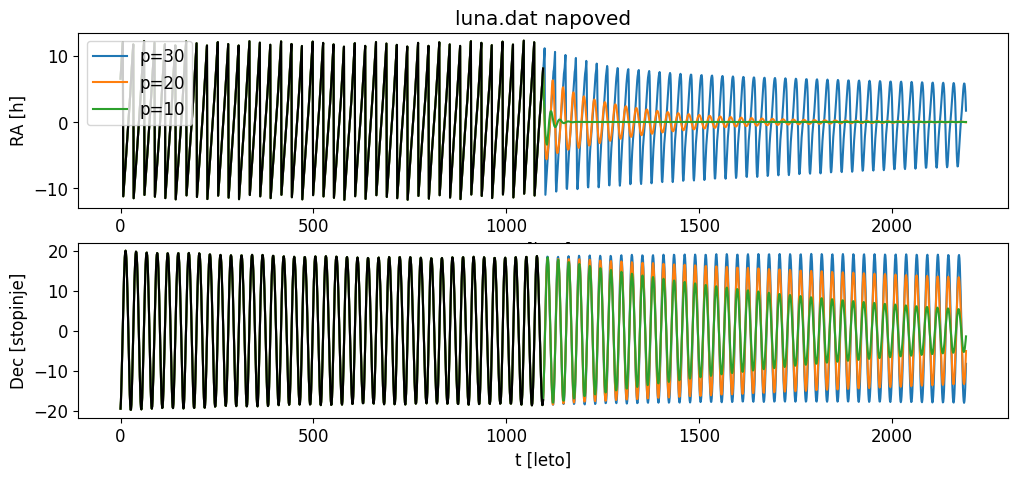

In [9]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(2, 1, 1)
ax.set_title('luna.dat napoved')
ax.set_ylabel('RA [h]')
ax.set_xlabel('t [leto]')
ax.plot(luna.index, luna_predict_30_Ra, label=f'p=30')
ax.plot(luna.index, luna_predict_20_Ra, label=f'p=20')
ax.plot(luna.index, luna_predict_10_Ra, label=f'p=10')
ax.plot(luna.index[:int(len(luna)/2)], luna_fit_Ra, color='black')
ax.legend(loc='upper left')
ax = fig.add_subplot(2, 1, 2)
ax.set_ylabel('Dec [stopinje]')
ax.set_xlabel('t [leto]')
ax.plot(luna.index, luna_predict_30_Dec, label=f'p=30')
ax.plot(luna.index, luna_predict_20_Dec, label=f'p=20')
ax.plot(luna.index, luna_predict_10_Dec, label=f'p=10')
ax.plot(luna.index[:int(len(luna)/2)], luna_fit_Dec, color='black')

In [11]:
# Future prediction

luna_fit_x = luna['x'].values[:int(len(luna)/2)]
luna_fit_y = luna['y'].values[:int(len(luna)/2)]
luna_fit_z = luna['z'].values[:int(len(luna)/2)]

poles_10_x, adjusted_poles_10_x, luna_predict_10_x,_ = predict(luna_fit_x, 10, int(len(luna)/2), 'Reflect')
poles_10_y, adjusted_poles_10_y, luna_predict_10_y,_ = predict(luna_fit_y, 10, int(len(luna)/2), 'Reflect')
poles_10_z, adjusted_poles_10_z, luna_predict_10_z,_ = predict(luna_fit_z, 10, int(len(luna)/2), 'Reflect')
poles_20_x, adjusted_poles_20_x, luna_predict_20_x,_ = predict(luna_fit_x, 20, int(len(luna)/2), 'Reflect')
poles_20_y, adjusted_poles_20_y, luna_predict_20_y,_ = predict(luna_fit_y, 20, int(len(luna)/2), 'Reflect')
poles_20_z, adjusted_poles_20_z, luna_predict_20_z,_ = predict(luna_fit_z, 20, int(len(luna)/2), 'Reflect')
poles_30_x, adjusted_poles_30_x, luna_predict_30_x,_ = predict(luna_fit_x, 30, int(len(luna)/2), 'Reflect')
poles_30_y, adjusted_poles_30_y, luna_predict_30_y,_ = predict(luna_fit_y, 30, int(len(luna)/2), 'Reflect')
poles_30_z, adjusted_poles_30_z, luna_predict_30_z,_ = predict(luna_fit_z, 30, int(len(luna)/2), 'Reflect')
poles_50_x, adjusted_poles_50_x, luna_predict_50_x,_ = predict(luna_fit_x, 100, int(len(luna)/2), 'Reflect')
poles_50_y, adjusted_poles_50_y, luna_predict_50_y,_ = predict(luna_fit_y, 100, int(len(luna)/2), 'Reflect')
poles_50_z, adjusted_poles_50_z, luna_predict_50_z,_ = predict(luna_fit_z, 100, int(len(luna)/2), 'Reflect')

reflected_poles = np.array([z for z in poles_30_x if np.abs(z) > 1])

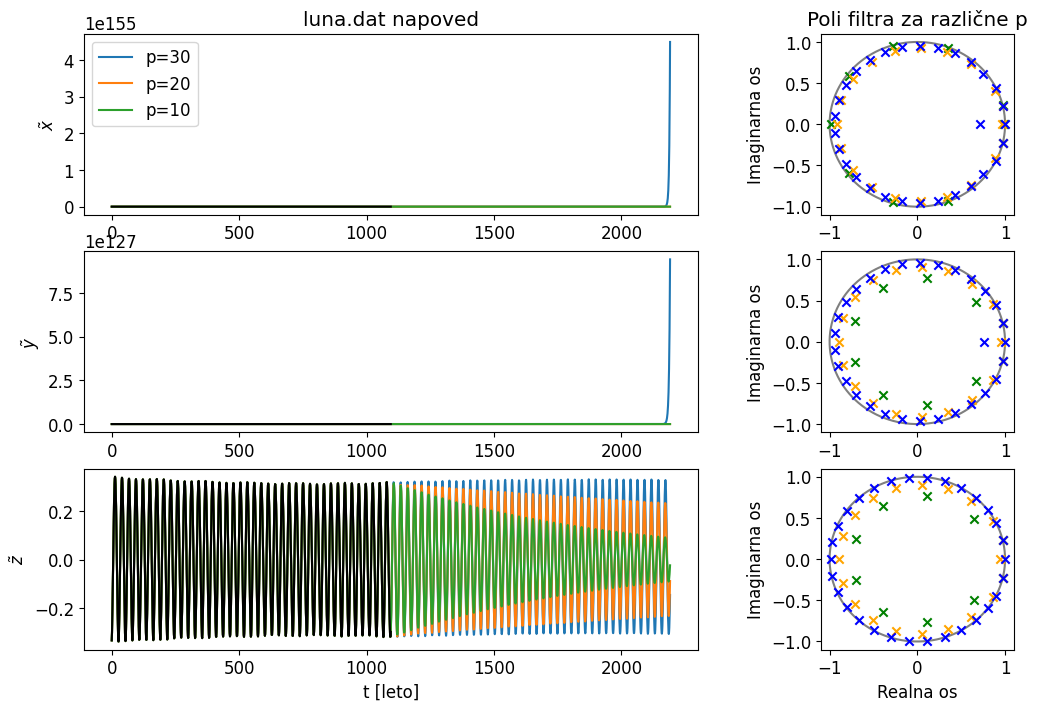

In [12]:
# Create the unit circle
theta = np.linspace(0, 2 * np.pi, 500)
unit_circle = np.exp(1j * theta)

fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(3, 9, (1, 6))
ax.set_title('luna.dat napoved')
ax.set_ylabel(r"$\tilde{x}$")
ax.plot(luna.index, luna_predict_30_x, label=f'p=30')
ax.plot(luna.index, luna_predict_20_x, label=f'p=20')
ax.plot(luna.index, luna_predict_10_x, label=f'p=10')
ax.plot(luna.index[:int(len(luna)/2)], luna['x'].values[:int(len(luna)/2)], color='black')
ax.legend(loc='upper left')

ax = fig.add_subplot(3, 9, (8, 9))
ax.set_title("Poli filtra za različne p")
ax.set_ylabel("Imaginarna os")
ax.plot(unit_circle.real, unit_circle.imag, 'black', alpha=0.5)
ax.scatter(adjusted_poles_10_x.real, adjusted_poles_10_x.imag, color='green', marker='x', label="p=30", zorder=5)
ax.scatter(adjusted_poles_20_x.real, adjusted_poles_20_x.imag, color='orange', marker='x', label="p=30", zorder=5)
# ax.scatter(reflected_poles.real, reflected_poles.imag, color='blue', label="p=30", zorder=5, alpha=0.5)
ax.scatter(adjusted_poles_30_x.real, adjusted_poles_30_x.imag, color='blue', marker='x', label="p=30", zorder=5)

ax = fig.add_subplot(3, 9, (10, 15))
ax.set_ylabel(r"$\tilde{y}$")
ax.plot(luna.index, luna_predict_30_y, label=f'p=30')
ax.plot(luna.index, luna_predict_20_y, label=f'p=20')
ax.plot(luna.index, luna_predict_10_y, label=f'p=10')
ax.plot(luna.index[:int(len(luna)/2)], luna['y'].values[:int(len(luna)/2)], color='black')

ax = fig.add_subplot(3, 9, (17, 18))
ax.set_ylabel("Imaginarna os")
ax.plot(unit_circle.real, unit_circle.imag, 'black', alpha=0.5)
ax.scatter(adjusted_poles_10_y.real, adjusted_poles_10_y.imag, color='green', marker='x', label="p=30", zorder=5)
ax.scatter(adjusted_poles_20_y.real, adjusted_poles_20_y.imag, color='orange', marker='x', label="p=30", zorder=5)
# ax.scatter(reflected_poles.real, reflected_poles.imag, color='blue', label="p=30", zorder=5, alpha=0.5)
ax.scatter(adjusted_poles_30_y.real, adjusted_poles_30_y.imag, color='blue', marker='x', label="p=30", zorder=5)

ax = fig.add_subplot(3, 9, (19, 24))
ax.set_ylabel(r"$\tilde{z}$")
ax.set_xlabel(r"t [leto]")
ax.plot(luna.index, luna_predict_30_z, label=f'p=30')
ax.plot(luna.index, luna_predict_20_z, label=f'p=20')
ax.plot(luna.index, luna_predict_10_z, label=f'p=10')
ax.plot(luna.index[:int(len(luna)/2)], luna['z'].values[:int(len(luna)/2)], color='black')

ax = fig.add_subplot(3, 9, (26, 27))
ax.set_ylabel("Imaginarna os")
ax.set_xlabel("Realna os")
ax.plot(unit_circle.real, unit_circle.imag, 'black', alpha=0.5)
ax.scatter(adjusted_poles_10_z.real, adjusted_poles_10_z.imag, color='green', marker='x', label="p=30", zorder=5)
ax.scatter(adjusted_poles_20_z.real, adjusted_poles_20_z.imag, color='orange', marker='x', label="p=30", zorder=5)
# ax.scatter(reflected_poles.real, reflected_poles.imag, color='blue', label="p=30", zorder=5, alpha=0.5)
ax.scatter(adjusted_poles_30_z.real, adjusted_poles_30_z.imag, color='blue', marker='x', label="p=30", zorder=5)

In [11]:
ps = np.array([10, 20, 30])

MSE_10_x = np.sum((luna_predict_10_x[int(len(luna)/2):] - luna['x'].values[int(len(luna)/2):])**2)
MSE_20_x = np.sum((luna_predict_20_x[int(len(luna)/2):] - luna['x'].values[int(len(luna)/2):])**2)
MSE_30_x = np.sum((luna_predict_30_x[int(len(luna)/2):] - luna['x'].values[int(len(luna)/2):])**2)
MSE_x = np.array([MSE_10_x, MSE_20_x, MSE_30_x])

MSE_10_y = np.sum((luna_predict_10_y[int(len(luna)/2):] - luna['y'].values[int(len(luna)/2):])**2)
MSE_20_y = np.sum((luna_predict_20_y[int(len(luna)/2):] - luna['y'].values[int(len(luna)/2):])**2)
MSE_30_y = np.sum((luna_predict_30_y[int(len(luna)/2):] - luna['y'].values[int(len(luna)/2):])**2)
MSE_y = np.array([MSE_10_y, MSE_20_y, MSE_30_y])

MSE_10_z = np.sum((luna_predict_10_z[int(len(luna)/2):] - luna['z'].values[int(len(luna)/2):])**2)
MSE_20_z = np.sum((luna_predict_20_z[int(len(luna)/2):] - luna['z'].values[int(len(luna)/2):])**2)
MSE_30_z = np.sum((luna_predict_30_z[int(len(luna)/2):] - luna['z'].values[int(len(luna)/2):])**2)
MSE_z = np.array([MSE_10_z, MSE_20_z, MSE_30_z])

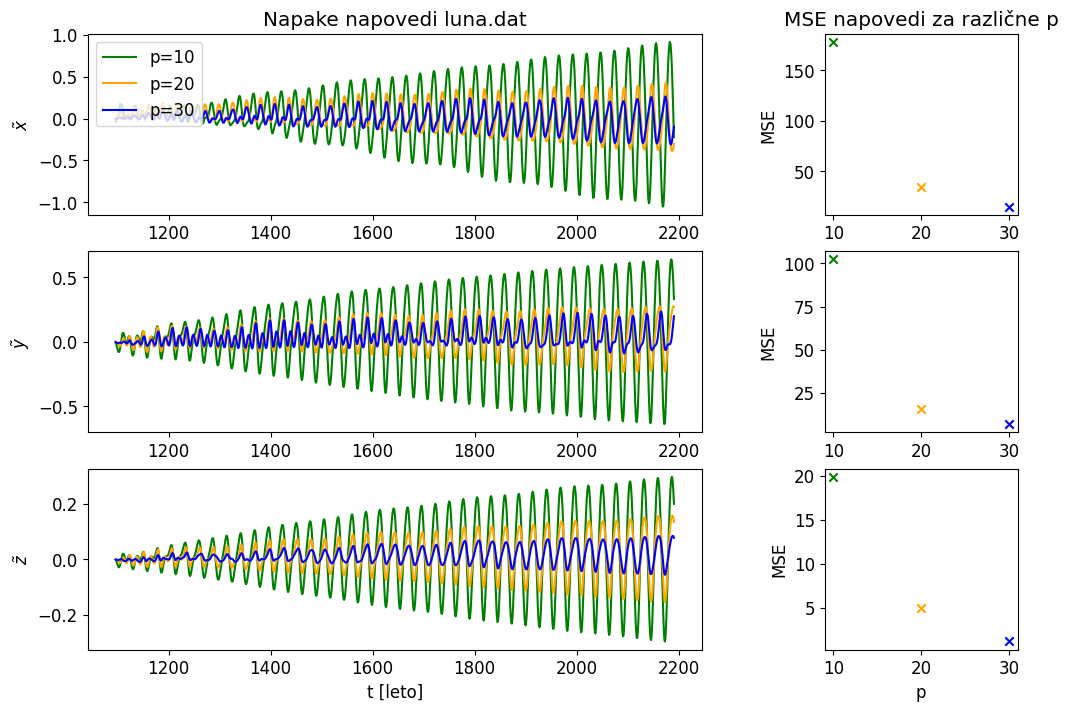

In [ ]:
# Napake napovedi

fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(3, 9, (1, 6))
ax.set_title('Napake napovedi luna.dat')
ax.set_ylabel(r"$\tilde{x}$")
ax.plot(luna.index[int(len(luna)/2):], luna_predict_10_x[int(len(luna)/2):] - luna['x'].values[int(len(luna)/2):], label=f'p=10', color='green')
ax.plot(luna.index[int(len(luna)/2):], luna_predict_20_x[int(len(luna)/2):] - luna['x'].values[int(len(luna)/2):], label=f'p=20', color='orange')
ax.plot(luna.index[int(len(luna)/2):], luna_predict_30_x[int(len(luna)/2):] - luna['x'].values[int(len(luna)/2):], label=f'p=30', color='blue')
ax.legend(loc='upper left')

ax = fig.add_subplot(3, 9, (8, 9))
ax.set_title("MSE napovedi za različne p")
ax.set_ylabel("MSE")
ax.scatter(ps[0], MSE_x[0], color='green', marker='x', label="p=30", zorder=5)
ax.scatter(ps[1], MSE_x[1], color='orange', marker='x', label="p=30", zorder=5)
ax.scatter(ps[2], MSE_x[2], color='blue', marker='x', label="p=30", zorder=5)

ax = fig.add_subplot(3, 9, (10, 15))
ax.set_ylabel(r"$\tilde{y}$")
ax.plot(luna.index[int(len(luna)/2):], luna_predict_10_y[int(len(luna)/2):] - luna['y'].values[int(len(luna)/2):], label=f'p=10', color='green')
ax.plot(luna.index[int(len(luna)/2):], luna_predict_20_y[int(len(luna)/2):] - luna['y'].values[int(len(luna)/2):], label=f'p=20', color='orange')
ax.plot(luna.index[int(len(luna)/2):], luna_predict_30_y[int(len(luna)/2):] - luna['y'].values[int(len(luna)/2):], label=f'p=30', color='blue')

ax = fig.add_subplot(3, 9, (17, 18))
ax.set_ylabel("MSE")
ax.scatter(ps[0], MSE_y[0], color='green', marker='x', label="p=30", zorder=5)
ax.scatter(ps[1], MSE_y[1], color='orange', marker='x', label="p=30", zorder=5)
ax.scatter(ps[2], MSE_y[2], color='blue', marker='x', label="p=30", zorder=5)

ax = fig.add_subplot(3, 9, (19, 24))
ax.set_ylabel(r"$\tilde{z}$")
ax.set_xlabel(r"t [leto]")
ax.plot(luna.index[int(len(luna)/2):], luna_predict_10_z[int(len(luna)/2):] - luna['z'].values[int(len(luna)/2):], label=f'p=10', color='green')
ax.plot(luna.index[int(len(luna)/2):], luna_predict_20_z[int(len(luna)/2):] - luna['z'].values[int(len(luna)/2):], label=f'p=20', color='orange')
ax.plot(luna.index[int(len(luna)/2):], luna_predict_30_z[int(len(luna)/2):] - luna['z'].values[int(len(luna)/2):], label=f'p=30', color='blue')

ax = fig.add_subplot(3, 9, (26, 27))
ax.set_ylabel("MSE")
ax.set_xlabel("p")
ax.scatter(ps[0], MSE_z[0], color='green', marker='x', label="p=30", zorder=5)
ax.scatter(ps[1], MSE_z[1], color='orange', marker='x', label="p=30", zorder=5)
ax.scatter(ps[2], MSE_z[2], color='blue', marker='x', label="p=30", zorder=5)

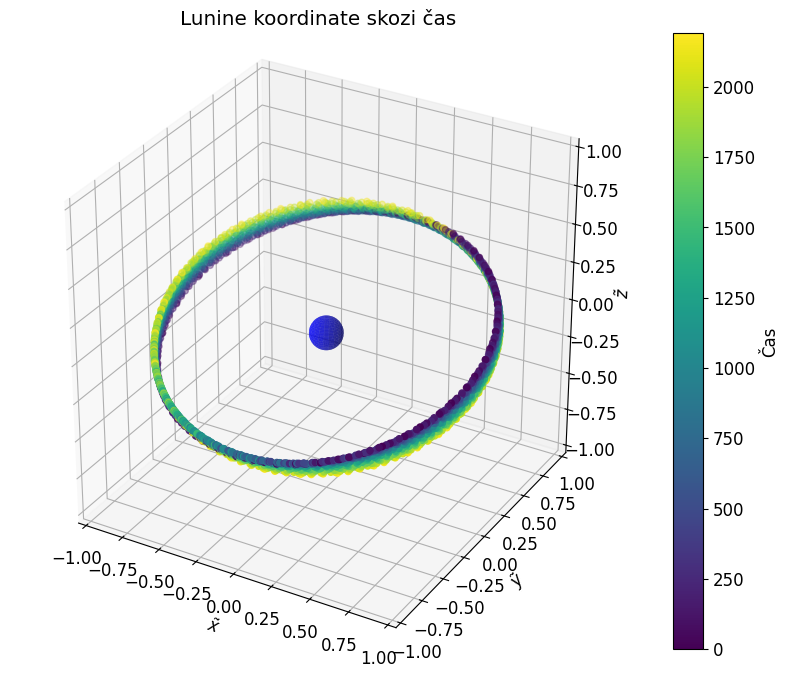

In [ ]:
# Normalize time data to use as a colormap scale
time = np.arange(len(luna))  # Assuming time is the index of rows in order
colors = plt.cm.viridis(time / max(time))  # Use the 'viridis' colormap

# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the Moon's coordinates with a color gradient
scatter = ax.scatter(luna['x'], luna['y'], luna['z'], c=time, cmap='viridis', marker='o')

# Create Earth as a sphere at the origin
u = np.linspace(0, 2 * np.pi, 100)  # Azimuth angle
v = np.linspace(0, np.pi, 100)      # Elevation angle
x_earth = 0.1 * np.outer(np.cos(u), np.sin(v))  # X coordinates of the sphere
y_earth = 0.1 * np.outer(np.sin(u), np.sin(v))  # Y coordinates of the sphere
z_earth = 0.1 * np.outer(np.ones_like(u), np.cos(v))  # Z coordinates of the sphere

# Plot the Earth sphere
ax.plot_surface(x_earth, y_earth, z_earth, color='blue', alpha=0.6, rstride=5, cstride=5)

# Add a color bar to indicate time progression
cbar = fig.colorbar(scatter, ax=ax, label='Čas')

# Label the axes
ax.set_xlabel(r'$\tilde{x}$')
ax.set_ylabel(r'$\tilde{y}$')
ax.set_zlabel(r'$\tilde{z}$')

ax.set_xlim((-1.01, 1.01))
ax.set_ylim((-1.01, 1.01))
ax.set_zlim((-1.01, 1.01))

# Add a title
ax.set_title('Lunine koordinate skozi čas')

# Set equal aspect ratio for better visualization
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1

# Show the plot
plt.show()
